In [179]:
from random import uniform


def generate_noisy_dataset(functions, f, x_range, n_samples, noise):
    res = []
    for _ in range(n_samples):
        x = uniform(*x_range)
        res.append([x] + [g(x) for g in functions] + [f(x) + uniform(-noise, noise)])
    return res


In [180]:
# reference: starter code of https://www.ccs.neu.edu/home/vip/teach/MLcourse/1_intro_DT_RULES_REG/hw1/HW1_26F.html
from numpy.linalg import inv, matmul
import numpy as np


#fit a LR model
def fit(data):
    data = np.array(data)
    x, y = data[:, :-1], data[:, -1]
    n = x.shape[0]
    x_aug = np.concatenate([x, np.ones((n, 1))], axis=1)# add intercept
    w = matmul(inv(matmul(x_aug.T, x_aug)), matmul(x_aug.T, y))  # use close form to get weights.
    return w

# use the weight to predict
def predict(data, w):
    data = np.concatenate([data, np.ones((data.shape[0], 1))], axis=1)
    return matmul(data, w)

#calculate rmse
def evaluate_model(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))


In [181]:
# reference: starter code of https://www.ccs.neu.edu/home/vip/teach/MLcourse/1_intro_DT_RULES_REG/hw1/HW1_26F.html
import matplotlib.pyplot as plt


def variance(y):
    return np.var(y)


def candidate_thresholds(column):
    values = np.unique(column)
    return [(values[i] + values[i + 1]) / 2 for i in range(len(values) - 1)]


class tree_node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        return self.value is not None


class decision_tree:
    def __init__(self):
        self.impurity = variance

    def fit(self, x, y, min_record=2):
        self.x_min, self.x_max = x[:, 0].min(), x[:, 0].max()
        self.n_features = x.shape[1]
        self.root = self._grow(x, y, min_record)
        return self

    def _leaf_value(self, y):
        return np.mean(y)

    def _grow(self, x, y, min_record):
        n, m = x.shape

        if n < min_record:
            return tree_node(value=self._leaf_value(y))
        parent_impurity = self.impurity(y)
        best_gain, best_feature, best_threshold = 0.0, None, None

        # greedy search on all features and all possible thresholds
        for feature in range(m):
            for threshold in candidate_thresholds(x[:, feature]):
                left_mask = x[:, feature] < threshold #akk the data points that are less than the threshold goes to the left
                right_mask = ~left_mask

                y_left, y_right = y[left_mask], y[right_mask]
                weighted_child_impurity = (len(y_left) * self.impurity(y_left) + len(y_right) * self.impurity(
                    y_right)) / len(
                    y) # calculate the weighted impurity of the child nodes
                gain = parent_impurity - weighted_child_impurity # information gain

                if gain > best_gain:
                    best_gain, best_feature, best_threshold = gain, feature, threshold

        if best_feature is None:
            return tree_node(value=self._leaf_value(y))

        left_mask = x[:, best_feature] < best_threshold  ### recompute the partition using the winning (best_feature, best_threshold) before recursing
        left = self._grow(x[left_mask], y[left_mask], min_record)
        right = self._grow(x[~left_mask], y[~left_mask], min_record)
        return tree_node(feature=best_feature, threshold=best_threshold, left=left, right=right)

    def _predict_one(self, x, node):
        if node.is_leaf():
            return node.value
        branch = node.left if x[
                                  node.feature] < node.threshold else node.right  ### walk left or right at this node based on the split threshold)
        return self._predict_one(x, branch)

    def predict(self, x):
        return np.array([self._predict_one(row, self.root) for row in x])


    # take in the outer ax so it can plot the tree with the input data and the real function
    def visualize(self, ax):
        splits, node = [], self.root
        while node is not None:  # morris inorder traversal to get all the splits
            if node.left is None:
                node = node.right
            else:
                predecessor = node.left
                while predecessor.right is not None and predecessor.right is not node:
                    predecessor = predecessor.right
                if predecessor.right is None:
                    predecessor.right = node
                    node = node.left
                else:
                    predecessor.right = None
                    splits.append(node.threshold ** (1 / (node.feature + 1)))
                    node = node.right
        edges = np.array([self.x_min, *splits, self.x_max])# define the boundaries of the prediction intervals
        x = (edges[:-1] + edges[1:]) / 2 # calculate one midpoint for each interval
        x_plot = x[:, None] ** np.arange(1, self.n_features + 1) # build the feature matrix for the interval midpoints
        ax.stairs(self.predict(x_plot), edges, baseline=None,
                  color='orange', label='tree prediction') # predict once per interval and draw the resulting step function.
        for split in splits:
            ax.axvline(split, color='gray', linestyle='--', alpha=0.2)
        ax.set_xlabel('x')
        ax.set_ylabel('y')


data1: train rmse = 0.005646, test rmse = 0.005748
data2: train rmse = 0.058378, test rmse = 0.054363
data3: train rmse = 0.021426, test rmse = 0.020984
data4: train rmse = 0.060675, test rmse = 0.063628


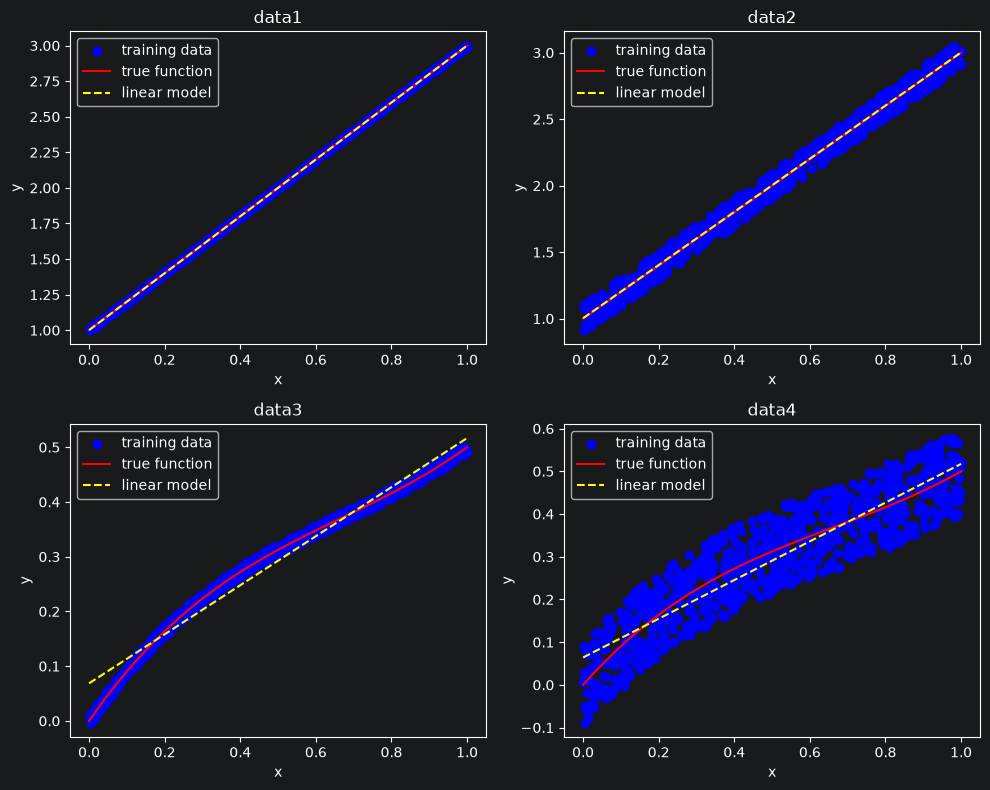

In [182]:
from sklearn.model_selection import train_test_split

#problem 2
data = {
    'data1': {
        'functions': [],
        'f': lambda x: 2 * x + 1,
        'x_range': [0, 1],
        'n_samples': 1000,
        'noise': 0.01
    },
    'data2': {
        'functions': [],
        'f': lambda x: 2 * x + 1,
        'x_range': [0, 1],
        'n_samples': 1000,
        'noise': 0.1
    },
    'data3': {
        'functions': [],
        'f': lambda x: 0.5 * x ** 3 - x ** 2 + x,
        'x_range': [0, 1],
        'n_samples': 1000,
        'noise': 0.01
    },
    'data4': {
        'functions': [],
        'f': lambda x: 0.5 * x ** 3 - x ** 2 + x,
        'x_range': [0, 1],
        'n_samples': 1000,
        'noise': 0.1
    }
}

weights = {}
data_splits = {}

#for each combination of arguments, train and validate the model then plot it.
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, params) in zip(axes.flat, data.items()):
    dataset = np.array(generate_noisy_dataset(**params))
    train, test = train_test_split(dataset, test_size=0.2)
    data_splits[name] = (train, test)
    w = fit(train)
    weights[name] = w
    train_mse = evaluate_model(predict(train[:, :-1], w), train[:, -1])
    test_mse = evaluate_model(predict(test[:, :-1], w), test[:, -1])
    print(f"{name}: train rmse = {train_mse:.6f}, test rmse = {test_mse:.6f}")

    x = np.linspace(*params['x_range'], 1000)
    ax.scatter(train[:, 0], train[:, -1], label='training data', color='blue')
    ax.plot(x, params['f'](x), label='true function', color='red')
    ax.plot(x, predict(x[:, None], w), '--', label='linear model', color='yellow')
    ax.set_title(f"{name}")
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
plt.tight_layout()
plt.show()


data5: train rmse = 0.005817, test rmse = 0.005650
data6: train rmse = 0.057150, test rmse = 0.059683
data7: train rmse = 0.005698, test rmse = 0.005760
data8: train rmse = 0.057535, test rmse = 0.054033


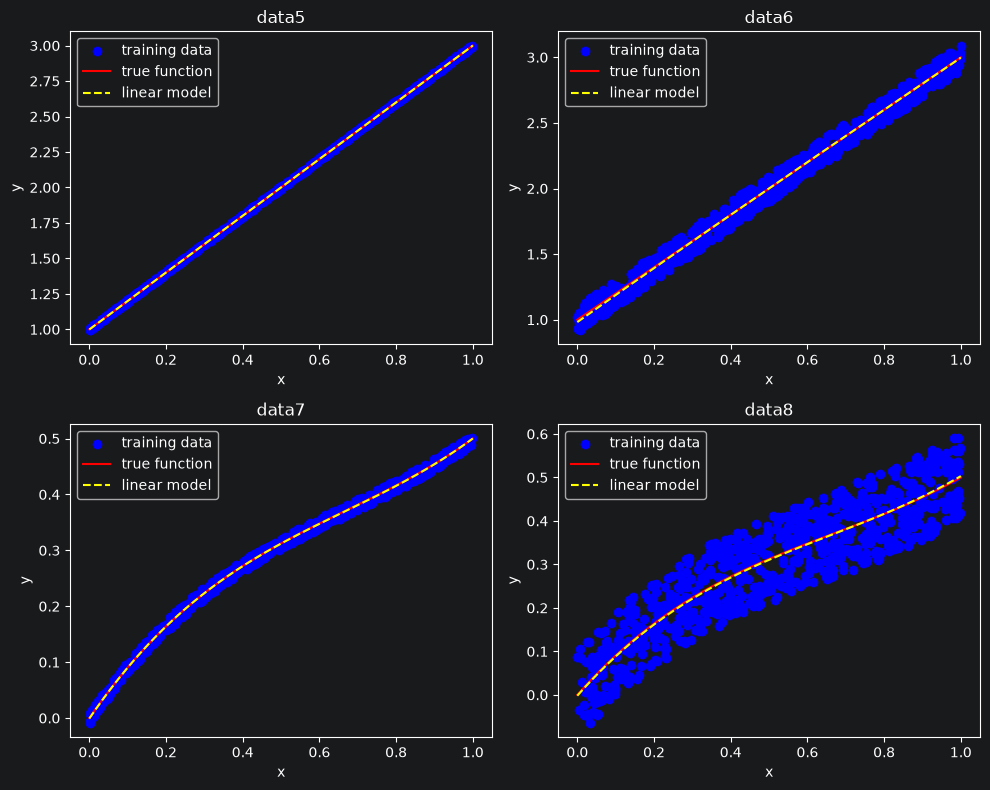

In [183]:

extra = {
    'data5': {
        'functions': [lambda x: x ** 2, lambda x: x ** 3],
        'f': lambda x: 2 * x + 1,
        'x_range': [0, 1],
        'n_samples': 1000,
        'noise': 0.01
    },
    'data6': {
        'functions': [lambda x: x ** 2, lambda x: x ** 3],
        'f': lambda x: 2 * x + 1,
        'x_range': [0, 1],
        'n_samples': 1000,
        'noise': 0.1
    },
    'data7': {
        'functions': [lambda x: x ** 2, lambda x: x ** 3],
        'f': lambda x: 0.5 * x ** 3 - x ** 2 + x,
        'x_range': [0, 1],
        'n_samples': 1000,
        'noise': 0.01
    },
    'data8': {
        'functions': [lambda x: x ** 2, lambda x: x ** 3],
        'f': lambda x: 0.5 * x ** 3 - x ** 2 + x,
        'x_range': [0, 1],
        'n_samples': 1000,
        'noise': 0.1
    }
}
data.update(extra) # add the exta combination of arguments to the data set.

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, params) in zip(axes.flat, extra.items()):
    dataset = np.array(generate_noisy_dataset(**params))
    train, test = train_test_split(dataset, test_size=0.2)
    data_splits[name] = (train, test)
    w = fit(train)
    weights[name] = w
    train_mse = evaluate_model(predict(train[:, :-1], w), train[:, -1])
    test_mse = evaluate_model(predict(test[:, :-1], w), test[:, -1])
    print(f"{name}: train rmse = {train_mse:.6f}, test rmse = {test_mse:.6f}")

    x = np.linspace(*params['x_range'], 1000)# create 1000 points for plotting
    x_plot = np.column_stack([x] + [g(x) for g in params['functions']]) # recreate the input matrix (x and x^2, x^3)

    ax.scatter(train[:, 0], train[:, -1], label='training data', color='blue') # plot the training data
    ax.plot(x, params['f'](x), label='true function', color='red') # plot the true function
    ax.plot(x, predict(x_plot, w), '--', label='linear model', color='yellow') # plot the linear model
    ax.set_title(f"{name}")
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
plt.tight_layout()
plt.show()

In [184]:
x = 10
for i in range(1, 9):
    name = f'data{i}'
    params = data[name]
    x_new = np.array([[x] + [g(x) for g in params['functions']]])
    y_true = np.array([params['f'](x)])

    y_pred = predict(x_new, weights[name])
    mse = evaluate_model(y_pred, y_true)
    print(f"{name}: rmse = {mse:.6f}")

data1: rmse = 0.005651
data2: rmse = 0.004654
data3: rmse = 405.451052
data4: rmse = 405.403610
data5: rmse = 16.490751
data6: rmse = 19.828197
data7: rmse = 9.949148
data8: rmse = 5.052802


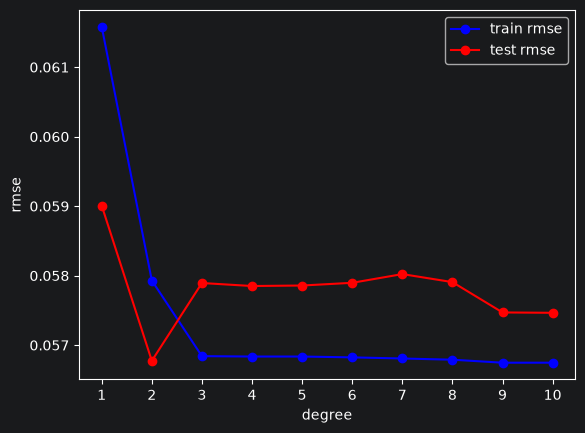

In [185]:
params = data['data8'].copy()
params['functions'] = [lambda x, k=k: x ** k for k in range(2, 11)]
dataset = np.array(generate_noisy_dataset(**params))
train, test = train_test_split(dataset, test_size=0.2)

train_rmse, test_rmse = [], []
degrees = range(1, 11)
for degree in degrees:
    train_d = np.concatenate([train[:, :degree], train[:, -1:]], axis=1)
    w = fit(train_d)
    train_rmse.append(evaluate_model(predict(train[:, :degree], w), train[:, -1]))
    test_rmse.append(evaluate_model(predict(test[:, :degree], w), test[:, -1]))

plt.figure()
plt.plot(degrees, train_rmse, 'o-', label='train rmse', color='blue')
plt.plot(degrees, test_rmse, 'o-', label='test rmse', color='red')
plt.xlabel('degree')
plt.ylabel('rmse')
plt.xticks(degrees)
plt.legend()
plt.show()


data1, min_records=1000: train rmse=0.575891, test rmse=0.580222
data1, min_records=50: train rmse=0.025826, test rmse=0.027533
data1, min_records=1: train rmse=0.000000, test rmse=0.008204


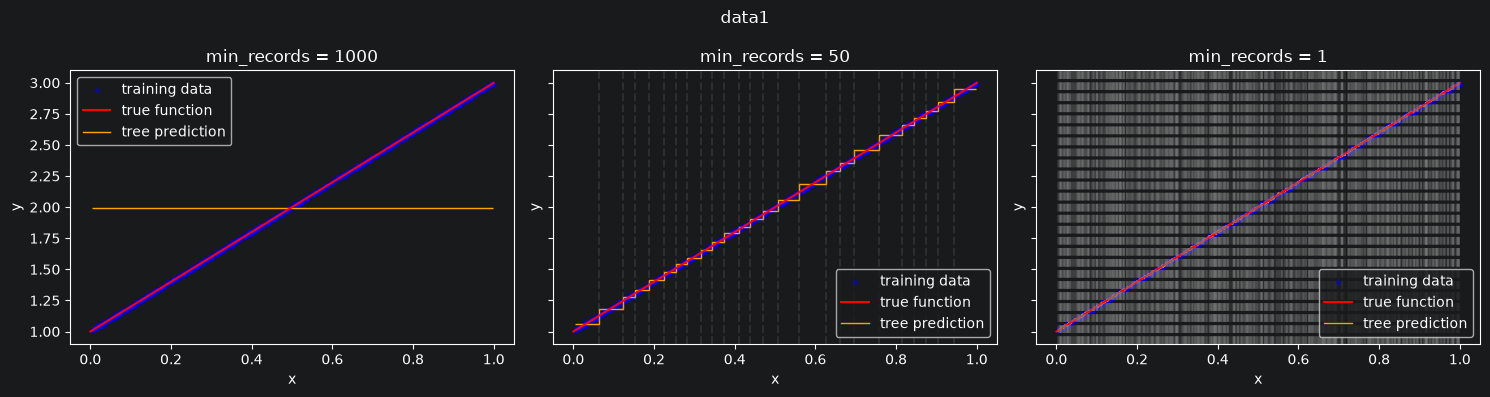

data2, min_records=1000: train rmse=0.587676, test rmse=0.598461
data2, min_records=50: train rmse=0.055103, test rmse=0.062752
data2, min_records=1: train rmse=0.000000, test rmse=0.073898


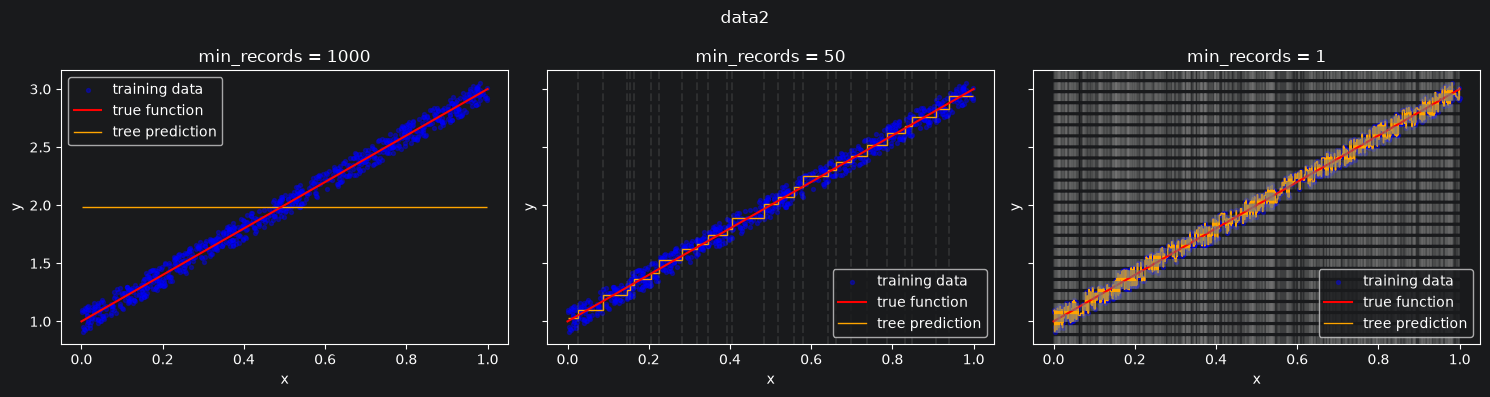

data3, min_records=1000: train rmse=0.128506, test rmse=0.129459
data3, min_records=50: train rmse=0.007580, test rmse=0.008522
data3, min_records=1: train rmse=0.000000, test rmse=0.008102


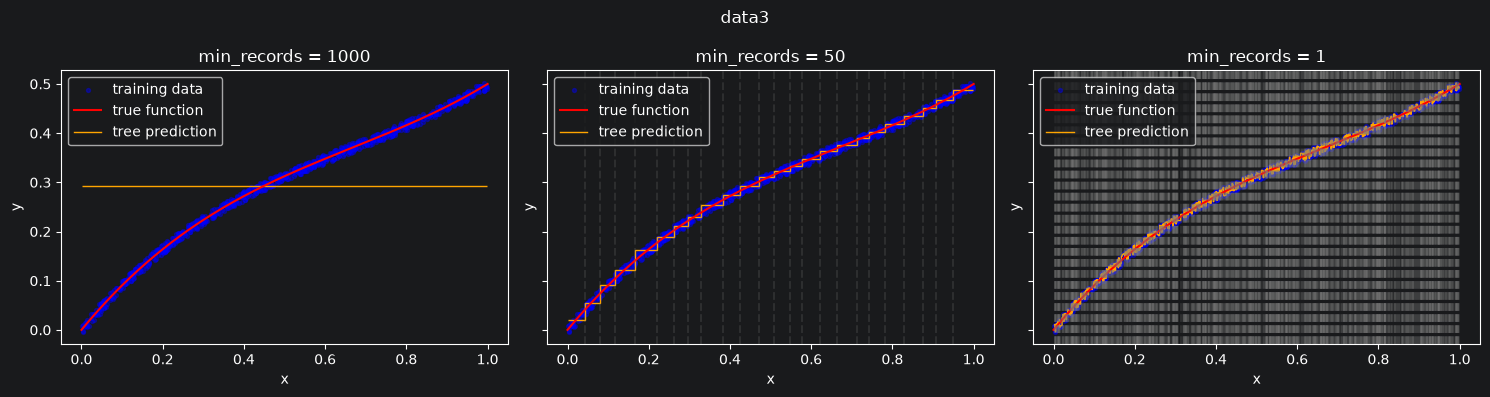

data4, min_records=1000: train rmse=0.144247, test rmse=0.146711
data4, min_records=50: train rmse=0.052928, test rmse=0.061223
data4, min_records=1: train rmse=0.000000, test rmse=0.086278


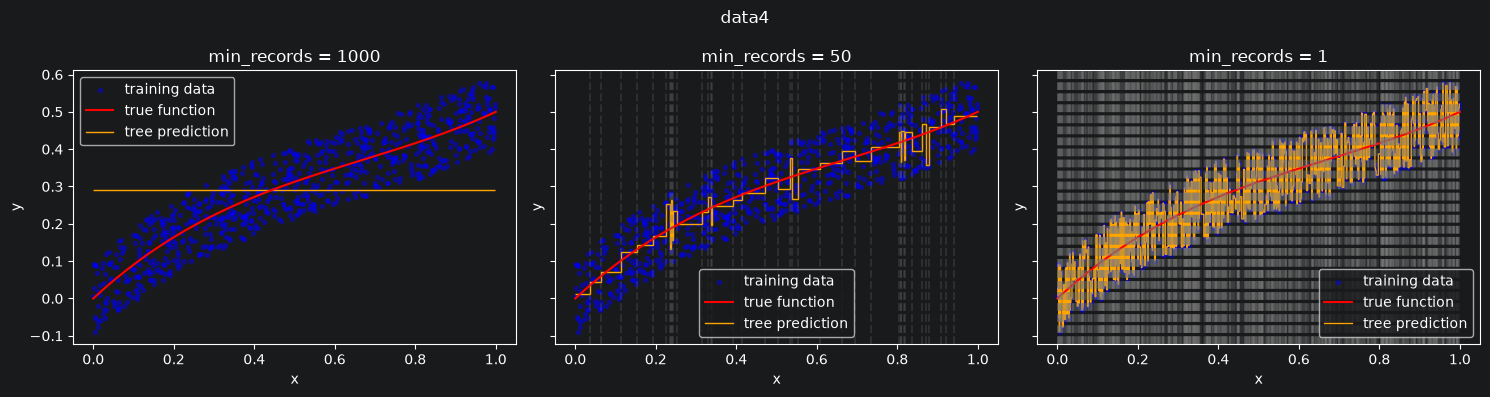

data5, min_records=1000: train rmse=0.598011, test rmse=0.544402
data5, min_records=50: train rmse=0.026131, test rmse=0.030393
data5, min_records=1: train rmse=0.000000, test rmse=0.008278


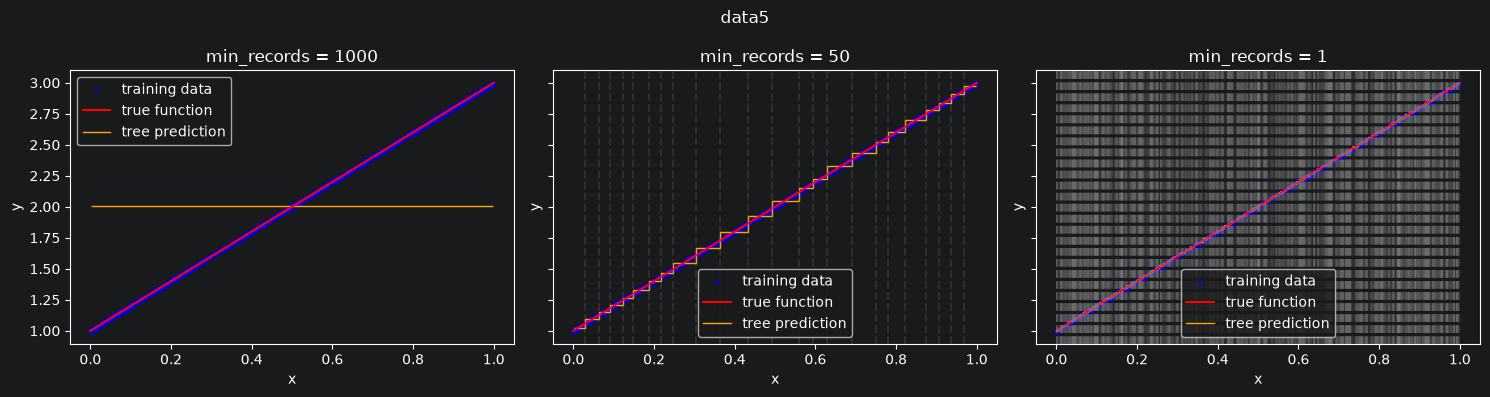

data6, min_records=1000: train rmse=0.594036, test rmse=0.608311
data6, min_records=50: train rmse=0.055026, test rmse=0.069053
data6, min_records=1: train rmse=0.000000, test rmse=0.082278


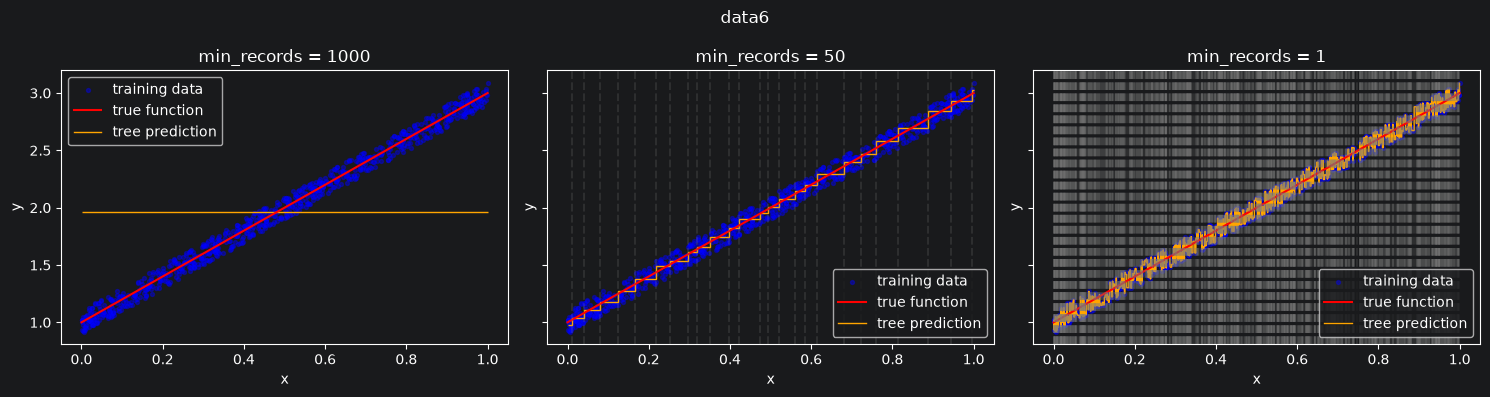

data7, min_records=1000: train rmse=0.131164, test rmse=0.139218
data7, min_records=50: train rmse=0.007756, test rmse=0.009610
data7, min_records=1: train rmse=0.000000, test rmse=0.007779


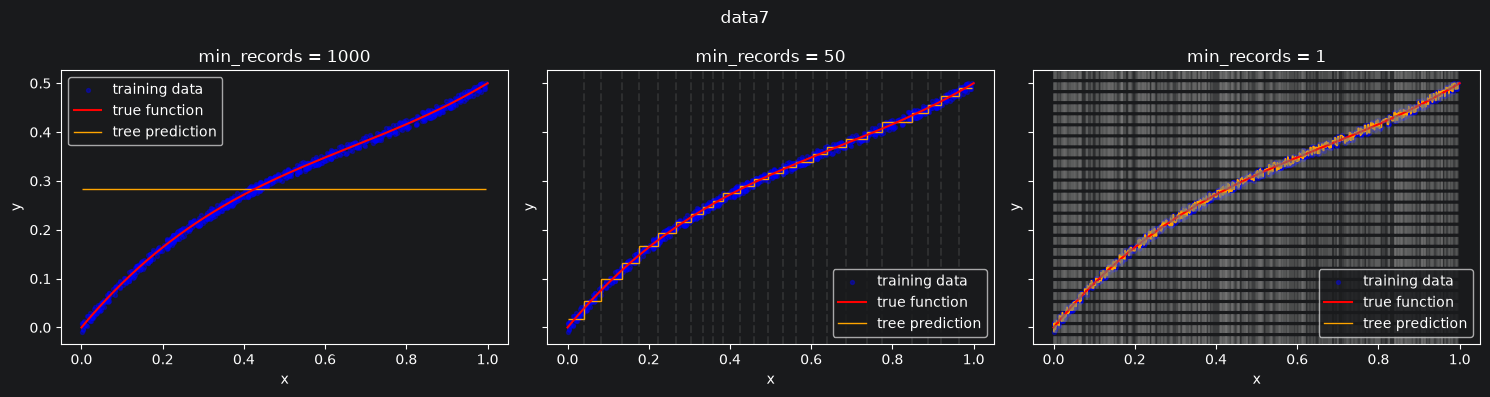

data8, min_records=1000: train rmse=0.143054, test rmse=0.156632
data8, min_records=50: train rmse=0.053532, test rmse=0.058403
data8, min_records=1: train rmse=0.000000, test rmse=0.075854


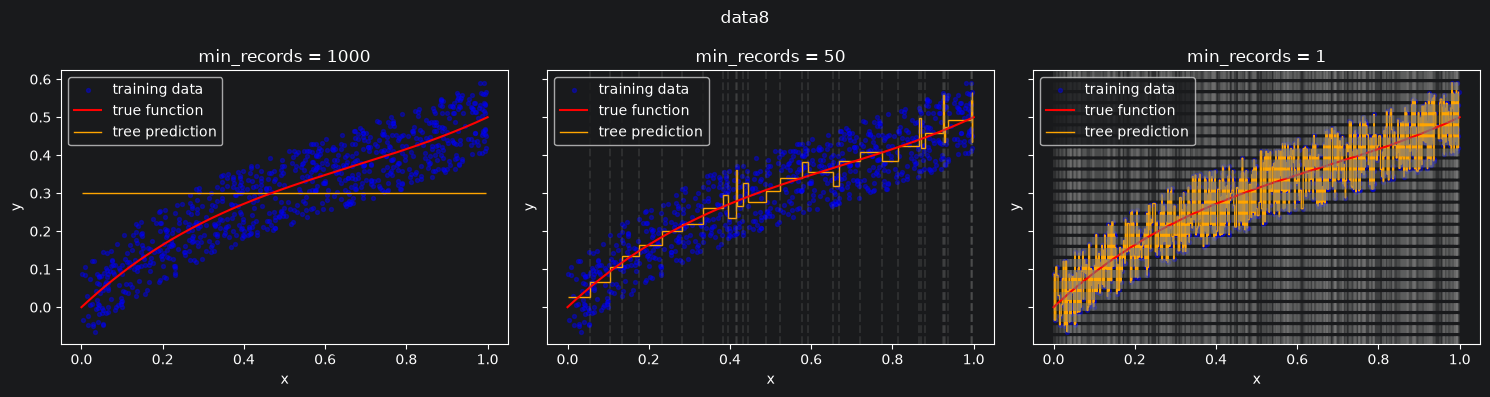

In [186]:
# reuse the linear regression train/test sets and test the tree
for name, params in data.items():
    train, test = data_splits[name]
    x = np.linspace(*params['x_range'], 200)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    fig.suptitle(f"{name}")
    for ax, min_records in zip(axes, [1000, 50, 1]):
        tree = decision_tree().fit(train[:, :-1], train[:, -1], min_record=min_records)
        train_rmse = evaluate_model(tree.predict(train[:, :-1]), train[:, -1])
        test_rmse = evaluate_model(tree.predict(test[:, :-1]), test[:, -1])
        print(f"{name}, min_records={min_records}: train rmse={train_rmse:.6f}, test rmse={test_rmse:.6f}")

        ax.scatter(train[:, 0], train[:, -1], s=8, alpha=0.4, color='blue', label='training data')
        ax.plot(x, params['f'](x), color='red', label='true function')
        tree.visualize(ax)
        ax.set_title(f"min_records = {min_records}")
        ax.legend()
    plt.tight_layout()
    plt.show()


min_records=2: train rmse=0.000000, test rmse=0.177555
min_records=4: train rmse=0.053469, test rmse=0.170356
min_records=8: train rmse=0.086872, test rmse=0.158989
min_records=16: train rmse=0.116185, test rmse=0.164693
min_records=32: train rmse=0.139105, test rmse=0.152421
min_records=64: train rmse=0.225090, test rmse=0.236812
min_records=128: train rmse=0.314697, test rmse=0.324546
min_records=256: train rmse=0.713767, test rmse=0.858392


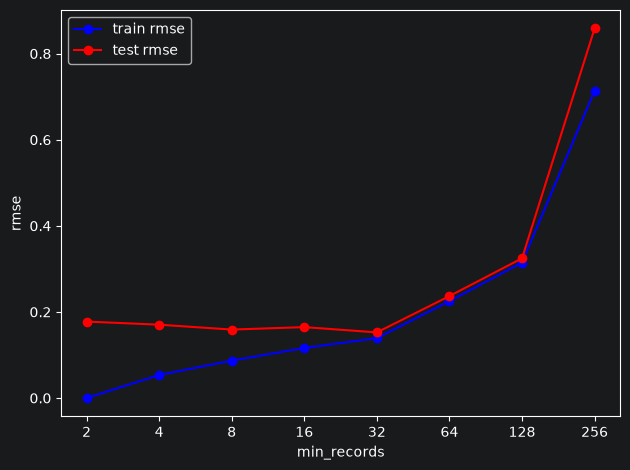

In [187]:
# sin data with uniform noise in [-0.2, 0.2]
dataset = np.array(generate_noisy_dataset(
    [], lambda x: np.sin(2 * np.pi * x), [0, 1], 200, 0.2
))
train, test = train_test_split(dataset, test_size=0.2)
min_records_vals = [2, 4, 8, 16, 32, 64, 128, 256]
train_rmse, test_rmse = [], []

for min_records in min_records_vals:
    tree = decision_tree().fit(train[:, :-1], train[:, -1], min_record=min_records)
    train_rmse.append(evaluate_model(tree.predict(train[:, :-1]), train[:, -1]))
    test_rmse.append(evaluate_model(tree.predict(test[:, :-1]), test[:, -1]))
    print(f"min_records={min_records}: train rmse={train_rmse[-1]:.6f}, test rmse={test_rmse[-1]:.6f}")

plt.figure()
plt.plot(min_records_vals, train_rmse, 'o-', label='train rmse', color='blue')
plt.plot(min_records_vals, test_rmse, 'o-', label='test rmse', color='red')
plt.xscale('log', base=2)
plt.xticks(min_records_vals, min_records_vals)
plt.xlabel('min_records')
plt.ylabel('rmse')
plt.legend()
plt.tight_layout()
plt.show()


